##  Gridded Model Verification

This script verifies output from a ML-based foundation model versus a
traditional NWP system for the atmospheric system. The defaults set at the top of
this script are tailored to the Alps-Clariden HPC system at CSCS.
- The NWP-model is called COSMO-E and is initialised with the ensemble mean of the analysis. Only surface level data is available in the archive at MeteoSwiss.
- The ML-model is called Neural-LAM and is initialised with the deterministic analysis.
- The Ground Truth is the same deterministic analysis as was used to train the ML-model.
- The boundary data for both models is IFS HRES from ECMWF, where the NWP-model got 6 hourly boundary updates and the ML model 12 hourly.

For more info about the COSMO model see:
- https://www.cosmo-model.org/content/model/cosmo/coreDocumentation/cosmo_io_guide_6.00.pdf
- https://www.research-collection.ethz.ch/handle/20.500.11850/720460

In [ ]:
import random
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import dask
import matplotlib.pyplot as plt
from dask.distributed import LocalCluster, Client
import numpy as np
from dask.diagnostics import ProgressBar
import pandas as pd
import xarray as xr
from pysteps.verification.salscores import sal  # requires scikit-image
from scipy.stats import kurtosis, skew, wasserstein_distance
from scores.categorical import ThresholdEventOperator as TEO
from scores.continuous import (
    mae,
    mean_error,
    mse,
    rmse,
)
from scores.continuous.correlation import pearsonr
from scores.spatial import fss_2d

**--------> Enter all your user settings in the cell below. <--------**

In [ ]:
### DEFAULTS ###
# This config will be applied to the data before any plotting. The data will be
# sliced and indexed according to the values in this config.The whole analysis and
# plotting will be done on the reduced data.

# IF YOUR DATA HAS DIFFERENT DIMENSIONS OR NAMES, PLEASE ADJUST THE CELLS BELOW
# MAKE SURE THE XARRAY DATASETS LOOK OKAY BEFORE RUNNING CHAPTER 1-4

# This path should point to the data that was used to train the model (default is mdp-datastore)
PATH_GROUND_TRUTH = "cosmo.datastore.zarr"
# This path should point to the NWP forecast data in zarr format
PATH_NWP = "cosmo_e_forecast.zarr"
# This path should point to the ML forecast data in zarr format (e.g. produced by neural-lam in `eval` mode)
PATH_ML = "preds_7_19_margin_interior_lr_0001_ar_12.zarr"
# This path should point to the boundary data in zarr format (default is MDP-datastore)
PATH_BOUNDARY = "ifs_7_19_margin_interior.datastore.zarr"

# elapsed forecast duration in steps for the forecast - [0] refers to the first forecast step at t+1
# this should be a list of integers
ELAPSED_FORECAST_DURATION = [0, 23, 47, 71, 95, 119]

# Select specific start_times for the forecast. This is the start and end of
# a slice in xarray. The start_time is included, the end_time is excluded.
# This should be a list of two strings in the format "YYYY-MM-DDTHH:MM:SS"
# Should be handy to evaluate certain dates, e.g. for a case study of a storm
START_TIMES = ["2019-10-31T00:00:00", "2020-10-23T13:00:00"]  # Full year
# START_TIMES = ["2020-02-08T00:00:00", "2020-02-15T00:00:00"]  # Ciara/Sabine

# Select specific plot times for the forecast (will be used to create maps for all variables)
# This only affect chapter one with the plotting of the maps
# Map creation takes a lot of time so this is limited to a single time step
# Simply rerun these cells and chapter one for more time steps
PLOT_TIME = "2020-02-07T00:00:00"

# Selection spatial grid in projection
# This is used to slice the data to a specific region
# This is in projection of the ground truth data
# The default is the whole domain [None, None]
X = [None, None]
Y = [None, None]

# Map projection settings for plotting
# This is the projection of the ground truth data
PROJECTION = ccrs.RotatedPole(
    pole_longitude=190,
    pole_latitude=43,
    central_rotated_longitude=10,
)

# Define how variables map between different data sources

# Define here which of the variables are available in the ground truth data
# The keys are the names of the variables in the ground truth data
# The values are the conventional names, used in this notebook
VARIABLES_GROUND_TRUTH = {
    # Surface and near-surface variables
    "T_2M": "temperature_2m",
    "U_10M": "wind_u_10m",
    "V_10M": "wind_v_10m",
    # "PMSL": "pressure_sea_level",
    "PS": "surface_pressure",
    "TOT_PREC": "precipitation",
    # "ASHFL_S": "surface_sensible_heat_flux",
    # "ASOB_S": "surface_net_shortwave_radiation",
    # "ATHB_S": "surface_net_longwave_radiation",
    # # Upper air variables - U component
    # "U_lev_6": "wind_u_level_6",
    # "U_lev_12": "wind_u_level_12",
    # "U_lev_20": "wind_u_level_20",
    # "U_lev_27": "wind_u_level_27",
    # "U_lev_31": "wind_u_level_31",
    # "U_lev_39": "wind_u_level_39",
    # "U_lev_45": "wind_u_level_45",
    # "U_lev_60": "wind_u_level_60",
    # # Upper air variables - V component
    # "V_lev_6": "wind_v_level_6",
    # "V_lev_12": "wind_v_level_12",
    # "V_lev_20": "wind_v_level_20",
    # "V_lev_27": "wind_v_level_27",
    # "V_lev_31": "wind_v_level_31",
    # "V_lev_39": "wind_v_level_39",
    # "V_lev_45": "wind_v_level_45",
    # "V_lev_60": "wind_v_level_60",
    # # Upper air variables - Pressure
    # "PP_lev_6": "pressure_level_6",
    # "PP_lev_12": "pressure_level_12",
    # "PP_lev_20": "pressure_level_20",
    # "PP_lev_27": "pressure_level_27",
    # "PP_lev_31": "pressure_level_31",
    # "PP_lev_39": "pressure_level_39",
    # "PP_lev_45": "pressure_level_45",
    # "PP_lev_60": "pressure_level_60",
    # # Upper air variables - Temperature
    # "T_lev_6": "temperature_level_6",
    # "T_lev_12": "temperature_level_12",
    # "T_lev_20": "temperature_level_20",
    # "T_lev_27": "temperature_level_27",
    # "T_lev_31": "temperature_level_31",
    # "T_lev_39": "temperature_level_39",
    # "T_lev_45": "temperature_level_45",
    # "T_lev_60": "temperature_level_60",
    # # Upper air variables - Relative Humidity
    # "RELHUM_lev_6": "relative_humidity_level_6",
    # "RELHUM_lev_12": "relative_humidity_level_12",
    # "RELHUM_lev_20": "relative_humidity_level_20",
    # "RELHUM_lev_27": "relative_humidity_level_27",
    # "RELHUM_lev_31": "relative_humidity_level_31",
    # "RELHUM_lev_39": "relative_humidity_level_39",
    # "RELHUM_lev_45": "relative_humidity_level_45",
    # "RELHUM_lev_60": "relative_humidity_level_60",
    # # Upper air variables - Vertical velocity
    # "W_lev_6": "vertical_velocity_level_6",
    # "W_lev_12": "vertical_velocity_level_12",
    # "W_lev_20": "vertical_velocity_level_20",
    # "W_lev_27": "vertical_velocity_level_27",
    # "W_lev_31": "vertical_velocity_level_31",
    # "W_lev_39": "vertical_velocity_level_39",
    # "W_lev_45": "vertical_velocity_level_45",
    # "W_lev_60": "vertical_velocity_level_60",
}

# Since the default ground_truth is the datastore that was used for model training
# the variables are identical to the VARIABLES_GROUND_TRUTH
VARIABLES_ML = VARIABLES_GROUND_TRUTH

# For the NWP-Forecast only a limited set of variables is available
# These variables are mapped to the same conventional names
# The script is flexible and will only calculate the NWP-metrics for the variables that are available
# The script will not break if some of the variables are not available
VARIABLES_NWP = {
    "wind_u_10m": "wind_u_10m",
    "wind_v_10m": "wind_v_10m",
    "precipitation_1hr": "precipitation",
    "pressure_sea_level": "pressure_sea_level",
    "surface_pressure": "surface_pressure",
    "temperature_2m": "temperature_2m",
}

# These variables are only used for chapter 1, the mapplots.
# They will be plotted for the ground truth, NWP and ML
VARIABLES_BOUNDARY = {
    # Surface and near-surface variables
    "mean_sea_level_pressure": "pressure_sea_level",
    "2m_temperature": "temperature_2m",
    "10m_u_component_of_wind": "wind_u_10m",
    "10m_v_component_of_wind": "wind_v_10m",
    "surface_pressure": "surface_pressure",
    # Upper air variables - U component
    "u_component_of_wind100hPa": "wind_u_level_6",
    "u_component_of_wind200hPa": "wind_u_level_12",
    "u_component_of_wind400hPa": "wind_u_level_20",
    "u_component_of_wind600hPa": "wind_u_level_27",
    "u_component_of_wind700hPa": "wind_u_level_31",
    "u_component_of_wind850hPa": "wind_u_level_39",
    "u_component_of_wind925hPa": "wind_u_level_45",
    "u_component_of_wind1000hPa": "wind_u_level_60",
    # Upper air variables - V component
    "v_component_of_wind100hPa": "wind_v_level_6",
    "v_component_of_wind200hPa": "wind_v_level_12",
    "v_component_of_wind400hPa": "wind_v_level_20",
    "v_component_of_wind600hPa": "wind_v_level_27",
    "v_component_of_wind700hPa": "wind_v_level_31",
    "v_component_of_wind850hPa": "wind_v_level_39",
    "v_component_of_wind925hPa": "wind_v_level_45",
    "v_component_of_wind1000hPa": "wind_v_level_60",
    # Upper air variables - Temperature
    "temperature100hPa": "temperature_level_6",
    "temperature200hPa": "temperature_level_12",
    "temperature400hPa": "temperature_level_20",
    "temperature600hPa": "temperature_level_27",
    "temperature700hPa": "temperature_level_31",
    "temperature850hPa": "temperature_level_39",
    "temperature925hPa": "temperature_level_45",
    "temperature1000hPa": "temperature_level_60",
    # Upper air variables - Vertical velocity
    "vertical_velocity100hPa": "vertical_velocity_level_6",
    "vertical_velocity200hPa": "vertical_velocity_level_12",
    "vertical_velocity400hPa": "vertical_velocity_level_20",
    "vertical_velocity600hPa": "vertical_velocity_level_27",
    "vertical_velocity700hPa": "vertical_velocity_level_31",
    "vertical_velocity850hPa": "vertical_velocity_level_39",
    "vertical_velocity925hPa": "vertical_velocity_level_45",
    "vertical_velocity1000hPa": "vertical_velocity_level_60",
}

# These variables will be used as `basename` for the vertical profiles.
# Since the input of the zarr archives is expected to have data vars that are 2D in space
# we need some base_name prefix to create the 3D variables
VARIABLES_3D = [
    "temperature_level",
    "wind_u_level",
    "wind_v_level",
    "pressure_level",
    "relative_humidity_level",
    "vertical_velocity_level",
]

# Add units dictionary after the imports
# units from zarr archives are not reliable and should rather be defined here
VARIABLE_UNITS = {
    # Surface and near-surface variables
    "temperature_2m": "K",
    "wind_u_10m": "m/s",
    "wind_v_10m": "m/s",
    "pressure_sea_level": "Pa",
    "surface_pressure": "Pa",
    "precipitation": "mm/h",
    "surface_sensible_heat_flux": "W/m²",
    "surface_net_shortwave_radiation": "W/m²",
    "surface_net_longwave_radiation": "W/m²",
    # Upper air variables
    "temperature_level": "K",
    "wind_u_level": "m/s",
    "wind_v_level": "m/s",
    "pressure_level": "Pa",
    "relative_humidity_level": "%",
    "vertical_velocity_level": "Pa/s",
}

# Define Thresholds for the ETS metric (Equitable Threat Score)
# These are calculated for wind and precipitation if available
# The score creates contingency tables for different thresholds
# The ETS is calculated for each threshold and the results are plotted
# The default thresholds are [0.1, 1, 5] for precipitation and [2.5, 5, 10] for wind
THRESHOLDS_PRECIPITATION = [0.1, 1, 5]  # mm/h
THRESHOLDS_WIND = [2.5, 5, 10]  # m/s

# Define the metrics to compute for the verification
# Some additional verifications will always be computed if the respective vars
# are available in the data
METRICS = [
    # "MAE",
    # "RMSE",
    # "MSE",
    # "ME",
    # "STDEV_ERR",
    # "RelativeMAE",
    # "RelativeRMSE",
    # "PearsonR",
    # "Wasserstein",
    "FSS"
]

# This setting is relevant for the mapplots in chapter 1
# Higher levels of ZOOM will zoom in on the map, cropping the boundary
ZOOM = 2  # Halves the extent of the mapplot

# For some chapters a random seed is required to reproduce the results
RANDOM_SEED = 42

# The DPI used in all plots in the notebook, export to pdf will always be 300 DPI
DPI = 100

# Subsample the data for faster plotting, 0.1 refers to 10% of the ml/nwp data
# sampled along the start_time, dimensions.
#
# The wasserstein metric and the SAL metric don't support lazy dask loading
# and can overflow memory without subsampling.
#
# By default all metrics/plots calculations are subsampled to speed up the process.
#
# There is a trade-off between speed and accuracy, that each user has to find.
SUBSAMPLE_FRACTION = 0.2

# If the data should be loaded into memory. Makes following calculations faster
# but requires enough memory to hold the data.
PRECOMPUTE_DATA = True

# Takes a long time, but if you see NaN in your output, you can set this to True
# This will check if there are any missing values in the data further below
# THIS NOTEBOOK WILL ONLY WORK RELIABLY IF THERE ARE NO MISSING VALUES
# If there are missing values, you have to interpolate them or remove them
CHECK_MISSING = False

# Font sizes for consistent plotting (different fig-sizes will require different font sizes)
FONT_SIZES = {
    "axes": 24,  # Axis labels and titles
    "ticks": 24,  # Tick labels
    "legend": 22,  # Legend text
    "cbar": 24,  # Colorbar labels
    "suptitle": 24,  # Figure suptitle
    "title": 24,  # Axes titles
    "stats": 22,  # Statistics text in plots
}


In [ ]:
# Create directories for plots and tables
Path("plots").mkdir(exist_ok=True)
Path("tables").mkdir(exist_ok=True)

# Colorblind-friendly color palette
COLORS = {
    "gt": "#000000",  # Black
    "ml": "#E69F00",  # Orange
    "nwp": "#56B4E9",  # Light blue
    "error": "#CC79A7",  # Pink
}

# Line styles and markers for accessibility
LINE_STYLES = {
    "gt": ("solid", "o"),
    "ml": ("dashed", "s"),
    "nwp": ("dotted", "^"),
}

# Set global font sizes
plt.rcParams.update({
    "font.size": FONT_SIZES["axes"],
    "axes.titlesize": FONT_SIZES["axes"],
    "axes.labelsize": FONT_SIZES["axes"],
    "xtick.labelsize": FONT_SIZES["ticks"],
    "ytick.labelsize": FONT_SIZES["ticks"],
    "legend.fontsize": FONT_SIZES["legend"],
    "figure.titlesize": FONT_SIZES["suptitle"],
})

# Colorblind-friendly colormap for 2D plots
COLORMAP = "viridis"

# Add level-specific units by reusing base units
required_levels = {
    int(key.split("_")[-1]) for key in VARIABLES_GROUND_TRUTH if "lev_" in key
}

# First, collect all the base variables and units we need to extend
base_level_vars = {}
for base_var, unit in VARIABLE_UNITS.items():
    if "_level" in base_var:
        base_level_vars[base_var] = unit

# Then create the level-specific entries
for level in required_levels:
    for base_var, unit in base_level_vars.items():
        VARIABLE_UNITS[f"{base_var}_{level}"] = unit


def save_plot(fig, name, time=None, remove_title=True, dpi=300):
    """Helper function to save plots consistently

    Args:
        fig: matplotlib figure object
        name (str): base name for the plot file
        time (datetime, optional): timestamp to append to filename
        remove_title (bool): remove suptitle/title hierarchically if True
        dpi (int): resolution for the saved figure, defaults to 300
    """
    if time is not None:
        name = f"{name}_{time.dt.strftime('%Y%m%d_%H').values}"

    # Sanitize filename by replacing problematic characters
    safe_name = name.replace("/", "_per_")

    # Normalize the path and ensure plots directory exists
    plot_dir = Path("plots")
    plot_dir.mkdir(exist_ok=True)

    # Remove titles if requested
    if remove_title:
        if hasattr(fig, "texts") and fig.texts:  # Check for suptitle
            fig.suptitle("")
        ax = fig.gca()
        if ax.get_title():
            ax.set_title("")

    pdf_path = plot_dir / f"{safe_name}.pdf"
    fig.savefig(pdf_path, bbox_inches="tight", dpi=dpi)


def export_table(df, name, caption=""):
    """Helper function to export tables consistently"""
    # Export to LaTeX with caption
    latex_str = df.to_latex(
        float_format="%.4f", caption=caption, label=f"tab:{name}"
    )
    with open(f"tables/{name}.tex", "w") as f:
        f.write(latex_str)

    # Export to CSV
    df.to_csv(f"tables/{name}.csv")

In [ ]:
ds_ml = xr.open_zarr(PATH_ML)
ds_ml = ds_ml.sel(state_feature=list(VARIABLES_ML.keys()))
ds_ml = ds_ml.sel(y=slice(*Y), x=slice(*X))
ds_ml = ds_ml.sel(start_time=slice(*START_TIMES))
for feature in ds_ml.state_feature.values:
    ds_ml[VARIABLES_ML[feature]] = ds_ml["state"].sel(state_feature=feature)
forecast_times = (
    ds_ml.start_time.values[:, None] + ds_ml.elapsed_forecast_duration.values
)
ds_ml = ds_ml.assign_coords(
    forecast_time=(
        ("start_time", "elapsed_forecast_duration"),
        forecast_times,
    )
)
ds_ml = ds_ml.drop_vars(["state", "state_feature", "time"])
ds_ml = ds_ml.transpose("start_time", "elapsed_forecast_duration", "x", "y")
ds_ml = ds_ml[
    [
        "start_time",
        "elapsed_forecast_duration",
        "x",
        "y",
        *VARIABLES_ML.values(),
    ]
]
ds_ml = ds_ml.isel(elapsed_forecast_duration=ELAPSED_FORECAST_DURATION)

ds_ml

In [ ]:
ds_gt = xr.open_zarr(PATH_GROUND_TRUTH)
ds_gt = ds_gt.set_index(grid_index=["y", "x"]).unstack("grid_index")
ds_gt = ds_gt.sel(y=slice(*Y), x=slice(*X))
ds_gt = ds_gt.sel(state_feature=list(VARIABLES_ML.keys()))
ds_gt = ds_gt.sel(split_name="test").drop_dims([
    "forcing_feature",
    "static_feature",
    "split_part",
])
for feature in ds_gt.state_feature.values:
    ds_gt[VARIABLES_ML[feature]] = ds_gt["state"].sel(state_feature=feature)
ds_gt = ds_gt.drop_vars([
    "state",
    "state_feature",
    "state_feature_units",
    "state_feature_long_name",
    "state_feature_source_dataset",
    "state__train__diff_mean",
    "state__train__diff_std",
    "state__train__mean",
    "state__train__std",
])
ds_gt = ds_gt.transpose("time", "x", "y")
ds_gt = ds_gt[
    [
        "time",
        "x",
        "y",
        *VARIABLES_GROUND_TRUTH.values(),
    ]
]
ds_gt = ds_gt.sel(time=np.unique(ds_ml.forecast_time.values.flatten()))
ds_gt


In [ ]:
zarr_path = (
    "/capstor/store/cscs/swissai/a01/sadamov/cosmo_e_forecast_fixed.zarr"
)
if not Path(zarr_path).exists():
    ds_nwp = xr.open_zarr(PATH_NWP)
    ds_nwp = ds_nwp.sel(y=slice(*Y), x=slice(*X), time=slice(*START_TIMES))
    ds_nwp = ds_nwp[VARIABLES_NWP.keys()].rename(VARIABLES_NWP)
    ds_nwp = ds_nwp.rename_dims({
        "lead_time": "elapsed_forecast_duration",
        "time": "start_time",
    })
    ds_nwp = ds_nwp.rename_vars({
        "lead_time": "elapsed_forecast_duration",
        "time": "start_time",
    })
    forecast_times = (
        ds_nwp.start_time.values[:, None]
        + ds_nwp.elapsed_forecast_duration.values
    )
    ds_nwp = ds_nwp.assign_coords(
        forecast_time=(
            ("start_time", "elapsed_forecast_duration"),
            forecast_times,
        )
    )

    # # Calculate hourly values by taking differences along elapsed_forecast_duration
    ds_nwp["precipitation"] = ds_nwp.precipitation.diff(
        dim="elapsed_forecast_duration"
    )
    # The NWP data starts at elapsed forecast duration 0 = start_time
    ds_nwp = ds_nwp.drop_isel(elapsed_forecast_duration=0).isel(
        elapsed_forecast_duration=ELAPSED_FORECAST_DURATION
    )

    ds_nwp = ds_nwp.transpose(
        "start_time", "elapsed_forecast_duration", "x", "y"
    )
    ds_nwp = ds_nwp[
        [
            "start_time",
            "elapsed_forecast_duration",
            "x",
            "y",
            *VARIABLES_NWP.values(),
        ]
    ]
    chunks = {
        "start_time": 1,
        "elapsed_forecast_duration": 1,
        "x": -1,  # or ds_nwp.sizes["x"]
        "y": -1,  # or ds_nwp.sizes["y"]
    }

    # Create encoding dict for each variable
    encoding = {}
    for var in ds_nwp.data_vars:
        # Get the actual dimensions for this variable
        dims = ds_nwp[var].dims
        # Create chunks tuple matching the variable's dimensions
        var_chunks = tuple(chunks.get(dim, -1) for dim in dims)
        encoding[var] = {"chunks": var_chunks}

    # First ensure Dask chunks match
    ds_nwp_rechunked = ds_nwp.chunk(chunks)

    # Then write to Zarr with progress bar and encoding
    with ProgressBar():
        ds_nwp_rechunked.to_zarr(
            zarr_path, mode="w", consolidated=True, encoding=encoding
        )


ds_nwp = xr.open_zarr(zarr_path)
ds_nwp

Check for missing data in any of the variables. If you have missing data, you need to handle it before running the verification.

In [ ]:
if CHECK_MISSING:
    missing_counts = dask.compute(
        {var: ds_gt[var].isnull().sum().values for var in ds_gt.data_vars},
        {var: ds_nwp[var].isnull().sum().values for var in ds_nwp.data_vars},
        {var: ds_ml[var].isnull().sum().values for var in ds_ml.data_vars},
    )
    # Unpack results
    gt_missing, nwp_missing, ml_missing = missing_counts

    # Print results
    print("Ground Truth")
    for var, count in gt_missing.items():
        print(f"{var}: {count} missing values")

    print("\nNWP Model")
    for var, count in nwp_missing.items():
        print(f"{var}: {count} missing values")

    print("\nML Model")
    for var, count in ml_missing.items():
        print(f"{var}: {count} missing values")

In [ ]:
assert ds_gt.sizes["x"] == ds_ml.sizes["x"]
assert ds_gt.sizes["x"] == ds_nwp.sizes["x"]
assert ds_gt.sizes["y"] == ds_ml.sizes["y"]
assert ds_gt.sizes["y"] == ds_nwp.sizes["y"]
assert ds_gt.sizes["time"] == len(
    np.unique(ds_ml.forecast_time.values.flatten())
)
assert ds_gt.sizes["time"] == len(
    np.unique(ds_nwp.forecast_time.values.flatten())
)

# Generate random indices for each dimension
rng = np.random.RandomState(RANDOM_SEED)
sampled_start_time_indices = np.sort(
    rng.choice(
        len(ds_ml.start_time),
        size=int(len(ds_ml.start_time) * SUBSAMPLE_FRACTION),
        replace=False,
    )
)

# with (
#     LocalCluster(
#         n_workers=4,
#         threads_per_worker=16,
#         memory_limit="96GB",
#         local_directory="/iopsstor/scratch/cscs/sadamov",  # Use fast local storage for spilling
#         dashboard_address=None,
#     ) as cluster
# ):
#     with Client(cluster) as client:
ds_ml_sampled = ds_ml.isel(start_time=sampled_start_time_indices)
ds_nwp_sampled = ds_nwp.isel(start_time=sampled_start_time_indices)
ds_gt_sampled = ds_gt.sel(time=ds_ml_sampled.forecast_time)
if PRECOMPUTE_DATA:
    with ProgressBar():
        print("Computing ML data")
        ds_ml_sampled = ds_ml_sampled.compute()
        print("Computing NWP data")
        ds_nwp_sampled = ds_nwp_sampled.compute()
        print("Computing GT data")
        ds_gt_sampled = ds_gt_sampled.compute()


### 1. Maps

**Random Time Selection:** A random time step is selected to avoid bias in the comparison, ensuring that the assessment is representative of typical model performance.

**Consistent Color Scales:** By setting the same minimum and maximum values across all datasets for each variable, we ensure that color differences in the plots reflect true discrepancies, not artifacts of scaling.

**Spatial Patterns:** The plots reveal how the ML model and NWP model represent geographical features like weather fronts, high and low-pressure systems, and temperature gradients. Visual comparisons can immediately highlight areas where the models perform well or poorly, guiding further investigation.

**Edge Effects:** Near the boundaries, artifacts may occur as the model does not calculate a loss in the boundary region.

In [ ]:
# Get coordinates
if hasattr(ds_gt, "longitude") and hasattr(ds_gt, "latitude"):
    lons = ds_gt.longitude.values
    lats = ds_gt.latitude.values
elif hasattr(ds_gt, "lon") and hasattr(ds_gt, "lat"):
    lons = ds_gt.lon.values
    lats = ds_gt.lat.values
lon_min = lons.min()
lon_max = lons.max()
lat_min = lats.min()
lat_max = lats.max()

# Transform domain bounds to rotated coordinates
transformer = PROJECTION.transform_points(
    ccrs.PlateCarree(),
    np.array([lon_min, lon_max]),
    np.array([lat_min, lat_max]),
)

# Get rotated coordinate bounds
rot_lon_min, rot_lon_max = transformer[:, 0].min(), transformer[:, 0].max()
rot_lat_min, rot_lat_max = transformer[:, 1].min(), transformer[:, 1].max()

In [ ]:
ds_boundary = xr.open_zarr(PATH_BOUNDARY)

temporal_dim = "time" if "time" in ds_boundary.dims else "analysis_time"
forecast_duration_dim = (
    "elapsed_forecast_duration"
    if "elapsed_forecast_duration" in ds_boundary.dims
    else None
)
dims_to_transpose = [
    dim
    for dim in [temporal_dim, forecast_duration_dim, "latitude", "longitude"]
    if dim is not None
]

ds_boundary = ds_boundary.sel(forcing_feature=list(VARIABLES_BOUNDARY.keys()))
ds_boundary = ds_boundary.sel(split_name="test").drop_dims([
    "split_part",
    "static_feature",
])
for feature in ds_boundary.forcing_feature.values:
    ds_boundary[VARIABLES_BOUNDARY[feature]] = ds_boundary["forcing"].sel(
        forcing_feature=feature
    )
ds_boundary = ds_boundary.drop_vars([
    "forcing",
    "forcing_feature",
    "forcing_feature_units",
    "forcing_feature_long_name",
    "forcing_feature_source_dataset",
    "forcing__train__diff_mean",
    "forcing__train__diff_std",
    "forcing__train__mean",
    "forcing__train__std",
])
ds_boundary = ds_boundary.set_index(grid_index=["latitude", "longitude"])
ds_boundary = ds_boundary.unstack("grid_index")
ds_boundary = ds_boundary.transpose(*dims_to_transpose)
longitude_new = np.where(
    ds_boundary["longitude"] > 180,
    ds_boundary["longitude"] - 360,
    ds_boundary["longitude"],
)
ds_boundary = ds_boundary.assign_coords(longitude=longitude_new).sortby([
    "longitude",
    "latitude",
])


lon_mesh, lat_mesh = np.meshgrid(ds_boundary.longitude, ds_boundary.latitude)
ds_boundary

In [ ]:
def set_map_extent(ax, zoom_factor=None, boundary_data=None):
    """Set the map extent based on zoom factor and boundary data."""
    if zoom_factor is not None and boundary_data is not None:
        # Get the boundary extent
        lon = (
            boundary_data.longitude
            if hasattr(boundary_data, "longitude")
            else boundary_data.lon
        )
        lat = (
            boundary_data.latitude
            if hasattr(boundary_data, "latitude")
            else boundary_data.lat
        )

        # Calculate center
        lon_center = (lon.max() + lon.min()) / 2
        lat_center = (lat.max() + lat.min()) / 2

        # Calculate ranges
        lon_range = (lon.max() - lon.min()) / zoom_factor
        lat_range = (lat.max() - lat.min()) / zoom_factor

        # Set new extent
        ax.set_extent(
            [
                lon_center - lon_range / 2,
                lon_center + lon_range / 2,
                lat_center - lat_range / 2,
                lat_center + lat_range / 2,
            ],
            crs=ccrs.PlateCarree(),
        )


def plot_field(ax, data, vmin, vmax):
    return ax.pcolormesh(
        data.longitude if hasattr(data, "longitude") else data.lon,
        data.latitude if hasattr(data, "latitude") else data.lat,
        data.values,
        transform=ccrs.PlateCarree(),
        vmin=vmin,
        vmax=vmax,
        cmap="viridis",
        shading="auto",
        rasterized=True,
    )


def add_map_features(axes):
    n_rows, _ = axes.shape
    for i, ax_row in enumerate(axes):
        for j, ax in enumerate(ax_row):
            ax.coastlines(resolution="50m")
            ax.add_feature(cfeature.BORDERS, linestyle="-", alpha=0.7)
            gl = ax.gridlines(
                draw_labels=True, dms=True, x_inline=False, y_inline=False
            )

            # Turn off all labels by default
            gl.top_labels = False
            gl.bottom_labels = False
            gl.left_labels = False
            gl.right_labels = False

            # Enable left labels only for leftmost column
            if j == 0:
                gl.left_labels = True

            # Enable bottom labels only for last row
            if i == n_rows - 1:
                gl.bottom_labels = True


def add_colorbar(fig, im, var):
    cbar_ax = fig.add_axes([0.2, 0.0, 0.6, 0.02])
    cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
    cbar.set_label(VARIABLE_UNITS[var])


In [ ]:
def create_comparison_maps(
    ds_gt,
    ds_ml,
    ds_nwp,
    ds_boundary=None,
    var=None,
    plot_time=None,
    step_size_gt=pd.Timedelta("1h"),
    random_seed=42,
    zoom_factor=None,
):
    # Handle variable selection
    variables = [var] if var else VARIABLES_GROUND_TRUTH.values()

    # Select time
    if plot_time is None:
        random.seed(random_seed)
        time_index = random.randint(0, len(ds_gt.time) - 1)
        time_selected = ds_ml.time[time_index].values
    else:
        time_selected = plot_time

    # Get number of forecast dimensions
    n_elapsed_forecast_durations = len(ds_ml.elapsed_forecast_duration)

    for var in variables:
        # Determine number of columns based on NWP data availability
        n_cols = 3 if (ds_nwp is not None and var in ds_nwp) else 2

        # Create figure with n_elapsed_forecast_durations rows and n_cols columns
        fig = plt.figure(
            figsize=(28, 6 * n_elapsed_forecast_durations), dpi=DPI
        )
        axes = np.array([
            [
                plt.subplot(
                    n_elapsed_forecast_durations,
                    n_cols,
                    i * n_cols + j + 1,
                    projection=PROJECTION,
                )
                for j in range(n_cols)
            ]
            for i in range(n_elapsed_forecast_durations)
        ])

        # Initialize arrays for global min/max
        arrays_for_minmax = []

        # First pass: collect all data for global min/max calculation
        for elapsed_forecast_dimension in ds_ml.elapsed_forecast_duration:
            # Select data for current forecast time
            ds_ml_time = ds_ml.sel(
                start_time=time_selected,
                elapsed_forecast_duration=elapsed_forecast_dimension,
            )
            ds_gt_time = ds_gt.sel(time=ds_ml_time.forecast_time)

            # Add ground truth and ML prediction to min/max arrays
            arrays_for_minmax.extend([
                ds_gt_time[var].values,
                ds_ml_time[var].values,
            ])

            # Add NWP data if available
            if ds_nwp is not None and var in ds_nwp:
                ds_nwp_time = ds_nwp.sel(
                    start_time=time_selected,
                    elapsed_forecast_duration=elapsed_forecast_dimension,
                )
                arrays_for_minmax.append(ds_nwp_time[var].values)

            # Add boundary data if available
            if ds_boundary is not None and var in ds_boundary:
                if "elapsed_forecast_duration" in ds_boundary:
                    # Determine number of steps based on time alignment
                    steps = (
                        2
                        if (
                            ds_boundary.sel(
                                analysis_time=time_selected - step_size_gt,
                                method="pad",
                            ).analysis_time.values
                            == time_selected - step_size_gt
                        )
                        else 1
                    )

                    # Get boundary data for current time
                    ds_boundary_var = ds_boundary[var].sel(
                        analysis_time=time_selected - steps * step_size_gt,
                        method="pad",
                    )
                    # Update forecast times
                    forecast_times = (
                        ds_boundary_var.analysis_time.values
                        + ds_boundary_var.elapsed_forecast_duration.values
                    )
                    ds_boundary_var["elapsed_forecast_duration"] = (
                        forecast_times
                    )
                    ds_boundary_var = ds_boundary_var.sel(
                        elapsed_forecast_duration=ds_ml_time.forecast_time,
                        method="pad",
                    )
                else:
                    ds_boundary_var = ds_boundary[var].sel(
                        time=ds_ml_time.forecast_time, method="pad"
                    )
                arrays_for_minmax.append(ds_boundary_var.values)

        # Calculate global min/max
        combined_array = np.concatenate([
            arr.flatten() for arr in arrays_for_minmax
        ])
        vmin, vmax = np.nanmin(combined_array), np.nanmax(combined_array)

        # Second pass: create plots
        for dim_idx, elapsed_forecast_dimension in enumerate(
            ds_ml.elapsed_forecast_duration
        ):
            # Select data for current forecast time
            ds_ml_time = ds_ml.sel(
                start_time=time_selected,
                elapsed_forecast_duration=elapsed_forecast_dimension,
            )
            ds_gt_time = ds_gt.sel(time=ds_ml_time.forecast_time)

            # Calculate forecast hours for titles
            forecast_hours = int(elapsed_forecast_dimension.values / 1e9 / 3600)

            # Plot boundary conditions if available
            if ds_boundary is not None and var in ds_boundary:
                if "elapsed_forecast_duration" in ds_boundary:
                    steps = (
                        2
                        if (
                            ds_boundary.sel(
                                analysis_time=time_selected - step_size_gt,
                                method="pad",
                            ).analysis_time.values
                            == time_selected - step_size_gt
                        )
                        else 1
                    )

                    ds_boundary_var = ds_boundary[var].sel(
                        analysis_time=time_selected - steps * step_size_gt,
                        method="pad",
                    )
                    forecast_times = (
                        ds_boundary_var.analysis_time.values
                        + ds_boundary_var.elapsed_forecast_duration.values
                    )
                    ds_boundary_var["elapsed_forecast_duration"] = (
                        forecast_times
                    )
                    ds_boundary_var = ds_boundary_var.sel(
                        elapsed_forecast_duration=ds_ml_time.forecast_time,
                        method="pad",
                    )
                else:
                    ds_boundary_var = ds_boundary[var].sel(
                        time=ds_ml_time.forecast_time, method="pad"
                    )

                for ax in axes[dim_idx]:
                    ax.contourf(
                        lon_mesh,
                        lat_mesh,
                        ds_boundary_var.values,
                        transform=ccrs.PlateCarree(),
                        cmap="viridis",
                        vmin=vmin,
                        vmax=vmax,
                        alpha=0.5,
                        levels=20,
                    )
                    if zoom_factor is not None:
                        set_map_extent(ax, zoom_factor, ds_boundary_var)

            # Plot ground truth
            im0 = plot_field(axes[dim_idx, 0], ds_gt_time[var], vmin, vmax)

            # Set titles
            if dim_idx == 0:
                axes[dim_idx, 0].set_title(f"Ground Truth\n+{forecast_hours}h")
                if ds_nwp is not None and var in ds_nwp:
                    axes[dim_idx, 1].set_title(f"NWP\n+{forecast_hours}h")
                    axes[dim_idx, 2].set_title(f"ML\n+{forecast_hours}h")
                else:
                    axes[dim_idx, 1].set_title(f"ML\n+{forecast_hours}h")
            else:
                axes[dim_idx, 0].set_title(f"+{forecast_hours}h")
                if ds_nwp is not None and var in ds_nwp:
                    axes[dim_idx, 1].set_title(f"+{forecast_hours}h")
                    axes[dim_idx, 2].set_title(f"+{forecast_hours}h")
                else:
                    axes[dim_idx, 1].set_title(f"+{forecast_hours}h")

            # Plot NWP and ML predictions
            col = 1
            if ds_nwp is not None and var in ds_nwp:
                ds_nwp_time = ds_nwp.sel(
                    start_time=time_selected,
                    elapsed_forecast_duration=elapsed_forecast_dimension,
                )
                plot_field(axes[dim_idx, col], ds_nwp_time[var], vmin, vmax)
                col += 1

            plot_field(axes[dim_idx, col], ds_ml_time[var], vmin, vmax)

        # Add common features and colorbar
        add_map_features(axes)
        add_colorbar(fig, im0, var)

        # Adjust layout and add title
        plt.subplots_adjust(
            top=0.92,
            bottom=0.05,
            hspace=0.2,
            wspace=0.05,
        )
        title = f"{var} starting at {str(time_selected.dt.date.values)} - {time_selected.dt.hour.values:02d} UTC"
        plt.suptitle(title, y=0.98)

        # Show and save plot
        plt.show()
        save_plot(fig, f"map_{var}_multi_efd", time_selected, dpi=DPI)
        plt.close()


In [ ]:
step_size_gt = pd.Timedelta(ds_gt.time.diff("time").min().values, "h")
ds_ml = ds_ml.assign_coords({
    "lon": (("x", "y"), ds_nwp.lon.values),
    "lat": (("x", "y"), ds_nwp.lat.values),
})
if PLOT_TIME is None:
    time_selected = None
else:
    time_selected = ds_ml.sel(start_time=PLOT_TIME).start_time
create_comparison_maps(
    ds_gt=ds_gt,
    ds_ml=ds_ml,
    ds_nwp=ds_nwp,
    ds_boundary=ds_boundary,
    plot_time=time_selected,
    step_size_gt=step_size_gt,
    zoom_factor=ZOOM,
)


#### Mean Error Plot Across All Start_Times

In [ ]:
def create_error_maps(ds_gt, ds_ml, ds_nwp=None, var=None):
    """Create average error maps for model outputs organized in subfigures."""
    variables = [var] if var else VARIABLES_GROUND_TRUTH.values()

    n_elapsed_forecast_durations = len(ds_ml.elapsed_forecast_duration)

    for var in variables:
        n_cols = 2 if (ds_nwp is not None and var in ds_nwp) else 1

        fig = plt.figure(
            figsize=(15.5, 5 * n_elapsed_forecast_durations), dpi=DPI
        )

        axes = np.array([
            [
                plt.subplot(
                    n_elapsed_forecast_durations,
                    n_cols,
                    i * n_cols + j + 1,
                    projection=PROJECTION,
                )
                for j in range(n_cols)
            ]
            for i in range(n_elapsed_forecast_durations)
        ])

        arrays_for_minmax = []
        for dim_idx, elapsed_forecast_dimension in enumerate(
            ds_ml.elapsed_forecast_duration
        ):
            forecast_hours = int(elapsed_forecast_dimension.values / 1e9 / 3600)

            ds_ml_time = ds_ml.isel(
                start_time=0, elapsed_forecast_duration=dim_idx
            )
            lons = (
                ds_ml_time.longitude
                if hasattr(ds_ml_time, "longitude")
                else ds_ml_time.lon
            )
            lats = (
                ds_ml_time.latitude
                if hasattr(ds_ml_time, "latitude")
                else ds_ml_time.lat
            )

            # Calculate errors using mean_error function
            obs_times = ds_ml.forecast_time.sel(
                elapsed_forecast_duration=elapsed_forecast_dimension
            )

            errors = {}
            errors["ml"] = mean_error(
                ds_ml[var].sel(
                    elapsed_forecast_duration=elapsed_forecast_dimension
                ),
                ds_gt[var].sel(time=obs_times),
                preserve_dims=["x", "y"],
            )
            arrays_for_minmax.append(errors["ml"])

            if ds_nwp is not None and var in ds_nwp:
                errors["nwp"] = mean_error(
                    ds_nwp[var].sel(
                        elapsed_forecast_duration=elapsed_forecast_dimension
                    ),
                    ds_gt[var].sel(time=obs_times),
                    preserve_dims=["x", "y"],
                )
                arrays_for_minmax.append(errors["nwp"])

            # Calculate symmetric bounds
            abs_max = max(abs(np.nanmax(arr)) for arr in arrays_for_minmax)
            abs_max = max(
                abs_max, abs(min(np.nanmin(arr) for arr in arrays_for_minmax))
            )
            vmin, vmax = -abs_max, abs_max

            if ds_nwp is not None and var in ds_nwp:
                plot_error_field(
                    axes[dim_idx, 0], lons, lats, errors["nwp"], vmin, vmax
                )
                axes[dim_idx, 0].set_title(
                    f"NWP\n+{forecast_hours}h"
                    if dim_idx == 0
                    else f"+{forecast_hours}h"
                )

            col_idx = 1 if ds_nwp is not None and var in ds_nwp else 0
            im = plot_error_field(
                axes[dim_idx, col_idx], lons, lats, errors["ml"], vmin, vmax
            )
            axes[dim_idx, col_idx].set_title(
                f"ML\n+{forecast_hours}h"
                if dim_idx == 0
                else f"+{forecast_hours}h"
            )

        add_map_features(axes)
        add_error_colorbar(fig, im, var)

        plt.subplots_adjust(
            top=0.9,
            bottom=0.05,
            hspace=0.2,
            wspace=0.05,
        )

        title = f"Mean Error in {var}"
        plt.suptitle(title, y=0.98)

        plt.show()
        save_plot(fig, f"mean_errormap_{var}_multi_efd")
        plt.close()


def plot_error_field(ax, lons, lats, data, vmin, vmax):
    return ax.pcolormesh(
        lons,
        lats,
        data,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        shading="auto",
        rasterized=True,
    )


def add_error_colorbar(fig, im, var):
    cbar_ax = fig.add_axes([0.2, 0.0, 0.6, 0.02])
    cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
    cbar.set_label(f"Mean Error ({VARIABLE_UNITS[var]})")


In [ ]:
if "lon" not in ds_ml_sampled.coords:
    ds_ml_sampled = ds_ml_sampled.assign_coords({
        "lon": (("x", "y"), ds_nwp.lon.values),
        "lat": (("x", "y"), ds_nwp.lat.values),
    })
if PLOT_TIME is None:
    time_selected = None
else:
    time_selected = ds_ml.sel(start_time=PLOT_TIME).start_time
create_error_maps(
    ds_gt=ds_gt,
    ds_ml=ds_ml_sampled,
    ds_nwp=ds_nwp_sampled,
)

### 2. Vertical Profiles
In this chapter, the focus is on assessing how the relative error between the ML
model and ground truth data.
Vertical profiles are essential for understanding the atmospheric structure and
processes at different pressure levels. Obviously these plots only work for 3D
variables.

**Relative Error Calculation:** Using percentage differences provides a
normalized measure of error that is comparable across variables and vertical
levels.

**Altitude-Specific Insights:** The plots reveal whether the ML model performs
consistently across different altitudes or if certain layers pose challenges.

**Atmospheric Dynamics:** Accurate representation of vertical profiles is
crucial for modeling phenomena like convection or jet stream anomalies.

**Pressure Level Interpretation:** Lower vertical levels correspond to higher
altitudes. Inverted axes help represent this correctly but can be
counterintuitive.

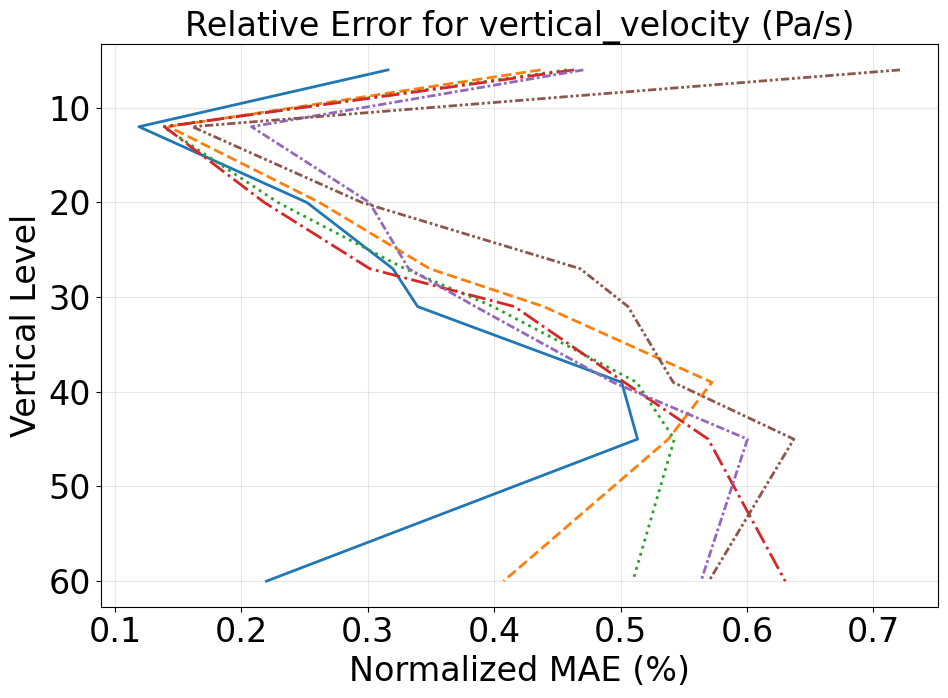

In [ ]:
def plot_vertical_errors(ds_gt, ds_ml, variables):
    """
    Plot vertical profiles of relative error for each variable separately.
    Variables with same prefix are stacked along level dimension.
    Shows separate lines for each forecast duration.
    """
    LINESTYLES = [
        "-",
        "--",
        ":",
        "-.",
        (0, (3, 1, 1, 1)),
        (0, (3, 1, 1, 1, 1, 1)),
    ]

    # Group variables by their prefix (without level)
    var_groups = {}
    for var in variables.values():
        if any(var.startswith(v) for v in VARIABLES_3D):
            base_name = "_".join(var.split("_")[:-2])
            level = int(var.split("_")[-1])

            if base_name not in var_groups:
                var_groups[base_name] = {"vars": [], "levels": []}
            var_groups[base_name]["vars"].append(var)
            var_groups[base_name]["levels"].append(level)
            var_groups[base_name]["unit"] = VARIABLE_UNITS[var]

    if len(var_groups) == 0:
        print("No 3D variables found in the dataset.")
        return

    # Plot each variable separately
    for base_name, group in var_groups.items():
        print("Processing", base_name)
        fig, ax = plt.subplots(figsize=(10, 7.5), dpi=DPI)

        # Sort by level
        sorted_idx = np.argsort(group["levels"])
        sorted_vars = [group["vars"][i] for i in sorted_idx]
        sorted_levels = [group["levels"][i] for i in sorted_idx]

        for dim_idx, elapsed_forecast_dimension in enumerate(
            ds_ml.elapsed_forecast_duration
        ):
            forecast_hours = int(elapsed_forecast_dimension.values / 1e9 / 3600)
            print("Processing duration", forecast_hours)

            # Get observation times for this forecast duration
            obs_times = ds_ml.forecast_time.sel(
                elapsed_forecast_duration=elapsed_forecast_dimension
            )

            # Stack variables for ground truth
            stacked_gt = xr.concat(
                [ds_gt[var].sel(time=obs_times) for var in sorted_vars],
                dim=pd.Index(sorted_levels, name="level"),
            )

            # Stack variables for ML predictions
            stacked_ml = xr.concat(
                [
                    ds_ml[var].sel(
                        elapsed_forecast_duration=elapsed_forecast_dimension
                    )
                    for var in sorted_vars
                ],
                dim=pd.Index(sorted_levels, name="level"),
            )

            # Calculate normalized MAE
            relative_error = (
                abs(stacked_ml - stacked_gt)
                / (
                    stacked_gt.max(dim=["start_time", "x", "y"]) 
                    - stacked_gt.min(dim=["start_time", "x", "y"])
                )
            ).mean(dim=["start_time", "x", "y"]) * 100

            # Plot with different linestyle for each duration
            ax.plot(
                relative_error,
                relative_error.level,
                linewidth=2,
                linestyle=LINESTYLES[dim_idx % len(LINESTYLES)],
                label=f"+{forecast_hours}h",
            )

        unit = group["unit"]
        ax.set_title(f"Relative Error for {base_name} ({unit})")
        ax.set_xlabel("Normalized MAE (%)")
        ax.set_ylabel("Vertical Level")
        ax.grid(True, alpha=0.3)
        ax.invert_yaxis()
        if base_name == list(var_groups.keys())[0]:
            ax.legend()

        plt.tight_layout()
        plt.show()
        save_plot(fig, f"vertical_profile_{base_name}")
        plt.close()

plot_vertical_errors(
    ds_gt,
    ds_ml_sampled,
    VARIABLES_GROUND_TRUTH,
)

### 3. Histograms
By examining these distributions, we can assess whether the ML model and NWP model accurately capture the variability and frequency of different atmospheric states.

**Distribution Shape:** The histograms show whether the models replicate the skewness, kurtosis, and overall shape of the ground truth data distributions.

**Extreme Values:** Identifying how the models handle extreme conditions, such as unusually high or low temperatures, is crucial for weather prediction and risk assessment.

**Normalization Needs:** Differences in scale between variables suggest that normalization may be necessary for accurate comparisons.

In [ ]:
for variable_name in VARIABLES_GROUND_TRUTH.values():
    fig, ax = plt.subplots(figsize=(16, 7), dpi=DPI)

    # Convert to numpy arrays
    data_gt = ds_gt_sampled[variable_name].values.flatten()
    data_ml = ds_ml_sampled[variable_name].values.flatten()

    # Create histograms for ground truth
    ax.hist(
        data_gt,
        bins=200,
        density=True,
        color=COLORS["gt"],
        label="Ground Truth",
        histtype="stepfilled",  # Use filled steps without edges
        linewidth=0,
    )

    # Plot NWP if available
    if variable_name in ds_nwp:
        data_nwp = ds_nwp_sampled[variable_name].values.flatten()
        ax.hist(
            data_nwp,
            bins=200,
            alpha=0.8,
            density=True,
            color=COLORS["nwp"],
            label="NWP Model Prediction",
            histtype="stepfilled",
            linewidth=0,
        )

    # Create histogram for ML
    ax.hist(
        data_ml,
        bins=200,
        alpha=0.8,
        density=True,
        color=COLORS["ml"],
        label="ML Model Prediction",
        histtype="stepfilled",
        linewidth=0,
    )

    # Add labels and title with adjusted positioning
    units = VARIABLE_UNITS[variable_name]
    ax.set_title(
        f"Distribution of {variable_name}", pad=20
    )  # Add padding below title
    ax.set_xlabel(f"{units}")  # Add units to x-axis label

    # Place legend in top left with some padding from the edge
    ax.legend(loc="upper left", bbox_to_anchor=(0.02, 0.98))

    # Adjust axis limits to leave space for both legend and table
    current_ylim = ax.get_ylim()
    ax.set_ylim(0, current_ylim[1] * 1.3)  # Increased padding for both elements

    # Calculate statistics
    stats_data = {
        "GT": [f"{skew(data_gt):.2f}", f"{kurtosis(data_gt):.2f}"],
        "ML": [f"{skew(data_ml):.2f}", f"{kurtosis(data_ml):.2f}"],
    }
    if variable_name in ds_nwp:
        stats_data["NWP"] = [
            f"{skew(data_nwp):.2f}",
            f"{kurtosis(data_nwp):.2f}",
        ]

    # Create and position table in top right with adjusted dimensions
    col_labels = ["Skewness", "Kurtosis"]
    row_labels = list(stats_data.keys())
    cell_text = [[stats_data[row][i] for i in range(2)] for row in row_labels]

    table = ax.table(
        cellText=cell_text,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc="center",
        loc="upper right",
        bbox=[
            0.68,
            0.6,
            0.3,
            0.35,
        ],  # Adjust position (x, y, width, height)
    )

    # Enhanced table styling
    table.auto_set_font_size(False)
    table.set_fontsize(22)

    # Adjust column widths and row heights
    for (row, col), cell in table._cells.items():
        cell.set_text_props(wrap=True)
        cell.set_facecolor("white")
        cell.set_alpha(0.9)
        cell.set_edgecolor("#D3D3D3")  # Light gray color

        # Adjust column widths and alignment
        if col == -1:  # Row header column
            cell.set_text_props(horizontalalignment="right")  # Right align text
        else:  # Data columns
            cell.set_text_props(
                horizontalalignment="center"
            )  # Keep center alignment for data

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    save_plot(fig, f"histogram_{variable_name}")
    plt.close()


### 4. Energy Spectra

This chapter examines how energy is distributed across different spatial scales
in the atmosphere by computing and comparing the energy spectra of both models.
This analysis is critical in understanding the models' capabilities to simulate
atmospheric processes ranging from large-scale weather systems to small-scale
turbulence.

**FFT Computation:** The Fast Fourier Transform (FFT) is used to transform spatial data into the frequency domain, revealing how different scales contribute to the overall energy. The energy spectra are averaged over latitudes.

**Scale Representation:** The energy spectra show whether the ML model captures the correct amount of energy at various spatial scales.

**Effective Resolution:** Identifying the effective resolution helps understand the smallest scales that the model can reliably simulate.

**Numerical Artifacts:** Limitations in numerical precision can introduce artifacts in the spectra, especially at the smallest scales.

To interpret the Log-Spectral Distance (LSD) metric:
The LSD quantifies the difference between two spectra, with lower values indicating better similarity (area between the two spectra). 

Lower values indicate better similarity between spectra
- LSD = 0 means identical spectra

Typical values depend on the specific application, but generally:
- LSD < 1: Good similarity
- 1 < LSD < 2: Moderate differences
- LSD > 2: Significant differences

In [ ]:
def calculate_energy_spectra(data):
    """Calculate the energy spectra of the given data using 2D FFT.

    Parameters
    ----------
    data : xarray.DataArray
        The data for which the energy spectra should be calculated.
        Expected dimensions must include 'x' and 'y', other dimensions will be handled automatically.

    Returns
    -------
    wavenumber : np.ndarray
        The isotropic wavenumbers.
    power : np.ndarray
        The power spectrum averaged over all non-spatial dimensions.
    effective_resolution : float
        The effective resolution of the model.
    """
    # Get grid spacing in meters
    dx = abs(float(data.x[1] - data.x[0]))
    dy = abs(float(data.y[1] - data.y[0]))

    # Identify spatial dimensions
    spatial_dims = ["y", "x"]

    # Move spatial dimensions to the end
    other_dims = [dim for dim in data.dims if dim not in spatial_dims]
    var_data = data.transpose(*other_dims, *spatial_dims).values

    # Reshape the array to combine all non-spatial dimensions
    shape = var_data.shape
    ny, nx = shape[-2:]

    if len(shape) > 2:
        var_data = var_data.reshape(-1, ny, nx)
    else:
        var_data = var_data[np.newaxis, :, :]

    # Compute 2D FFT
    fft_data = np.fft.fft2(var_data, axes=(-2, -1))
    power_spectrum = (np.abs(fft_data) ** 2).mean(axis=0)

    # Rest of the function remains the same
    # Get wavenumbers
    kx = np.fft.fftfreq(nx, d=dx)
    ky = np.fft.fftfreq(ny, d=dy)

    # Create 2D wavenumber grid
    kxx, kyy = np.meshgrid(kx, ky)
    k_mag = np.sqrt(kxx**2 + kyy**2)

    # Create wavenumber bins for azimuthal averaging
    k_bins = np.logspace(
        np.log10(k_mag[k_mag > 0].min()), np.log10(k_mag.max()), num=50
    )

    # Perform azimuthal averaging
    k_averaged = []
    power_averaged = []

    for i in range(len(k_bins) - 1):
        k_mask = (k_mag >= k_bins[i]) & (k_mag < k_bins[i + 1])
        if k_mask.any():
            k_averaged.append(np.mean(k_mag[k_mask]))
            power_averaged.append(np.mean(power_spectrum[k_mask]))

    # Convert to arrays
    k_averaged = np.array(k_averaged)
    power_averaged = np.array(power_averaged)

    # Calculate effective resolution
    effective_resolution = 1 / (4 * dx)

    # Remove first and last two wavenumbers
    return k_averaged[2:-2], power_averaged[2:-2], effective_resolution


def calculate_all_spectra(ds_gt, ds_ml, ds_nwp, variables):
    """Calculate and cache all energy spectra, including temporal evolution.

    Parameters
    ----------
    ds_gt : xarray.Dataset
        Ground truth dataset
    ds_ml : xarray.Dataset
        Machine learning model dataset
    ds_nwp : xarray.Dataset
        Numerical weather prediction model dataset
    variables : list
        List of variables to process

    Returns
    -------
    dict
        Nested dictionary containing wavenumbers, spectra and effective resolution
        for each dataset and variable, including temporal evolution
    """
    spectra_cache = {
        "gt": {},
        "ml": {"static": {}, "temporal": {}},
        "nwp": {"static": {}, "temporal": {}} if ds_nwp is not None else None,
    }

    for var in variables:
        if var not in ds_gt or var not in ds_ml:
            continue
        print(f"Calculating spectra for {var}...")

        # Calculate static spectra for ground truth
        k_gt, spec_gt, eff_res = calculate_energy_spectra(ds_gt[var])
        spectra_cache["gt"][var] = (k_gt, spec_gt, eff_res)

        # Calculate temporal spectra for ML model
        forecast_times = ds_ml.elapsed_forecast_duration.values
        ml_temporal = {}
        for time in forecast_times:
            data = ds_ml[var].sel(elapsed_forecast_duration=time)
            k, spec, _ = calculate_energy_spectra(data)
            ml_temporal[time] = (k, spec)

        spectra_cache["ml"]["temporal"][var] = ml_temporal
        spectra_cache["ml"]["static"][var] = calculate_energy_spectra(
            ds_ml[var]
        )

        # Calculate temporal spectra for NWP model if available
        if ds_nwp is not None and var in ds_nwp:
            nwp_temporal = {}
            for time in forecast_times:
                data = ds_nwp[var].sel(elapsed_forecast_duration=time)
                k, spec, _ = calculate_energy_spectra(data)
                nwp_temporal[time] = (k, spec)

            spectra_cache["nwp"]["temporal"][var] = nwp_temporal
            spectra_cache["nwp"]["static"][var] = calculate_energy_spectra(
                ds_nwp[var]
            )

    return spectra_cache


def plot_energy_spectra(spectra_cache, var, level=None, show_legend=False):
    """Plot energy spectra comparison using pre-calculated spectra.

    Parameters
    ----------
    spectra_cache : dict
        Cache containing pre-calculated spectra
    var : str
        Variable name to plot
    level : float, optional
        Vertical level in hPa
    show_legend : bool, optional
        Whether to show the legend (default: False)
    """
    k_gt, spec_gt, eff_res = spectra_cache["gt"][var]
    k_ml, spec_ml, _ = spectra_cache["ml"]["static"][var]

    fig, ax = plt.subplots(figsize=(11, 6.5), dpi=DPI)

    # Plot ground truth spectrum
    ax.loglog(
        k_gt,
        spec_gt,
        color=COLORS["gt"],
        label="Ground Truth",
        linestyle=LINE_STYLES["gt"][0],
        marker=LINE_STYLES["gt"][1],
        markevery=5,
    )

    # Plot NWP spectrum if available
    if spectra_cache["nwp"] and var in spectra_cache["nwp"]["static"]:
        k_nwp, spec_nwp, _ = spectra_cache["nwp"]["static"][var]
        ax.loglog(
            k_nwp,
            spec_nwp,
            color=COLORS["nwp"],
            label="NWP Model Prediction",
            linestyle=LINE_STYLES["nwp"][0],
            marker=LINE_STYLES["nwp"][1],
            markevery=3,
        )

    # Plot ML spectrum
    ax.loglog(
        k_ml,
        spec_ml,
        color=COLORS["ml"],
        label="ML Model Prediction",
        linestyle=LINE_STYLES["ml"][0],
        marker=LINE_STYLES["ml"][1],
        markevery=4,
    )

    # Plot effective resolution
    ax.axvline(
        eff_res,
        color="salmon",
        linestyle="--",
        label="Effective Model Resolution",
    )

    # Add LSD metric
    spec_nwp = (
        spectra_cache["nwp"]["static"][var][1]
        if spectra_cache["nwp"] and var in spectra_cache["nwp"]["static"]
        else None
    )
    add_lsd_to_plot(ax, spec_gt, spec_ml, spec_nwp)

    # Customize plot
    ax.set_xlabel("Wavenumber (1/m)")
    unit = VARIABLE_UNITS.get(var, "")
    ax.set_ylabel(f"Energy Density (({unit})² * m)")
    title = f"Energy Spectra Comparison for {var}"
    if level is not None:
        title += f" at Level {level} hPa"
    ax.set_title(title)
    if show_legend:
        ax.legend(loc='upper right')
    ax.grid(True, which="both", ls="--", alpha=0.5)

    # Save and display plot
    plot_name = f"energy_spectra_{var}"
    if level is not None:
        plot_name += f"_level_{level}"
    plt.tight_layout()
    plt.show()
    save_plot(fig, plot_name)
    plt.close()


def display_lsd_table(spectra_cache, variables, name, caption=""):
    """Display and export LSD metrics table using pre-calculated spectra.

    Parameters
    ----------
    spectra_cache : dict
        Cache containing pre-calculated spectra
    variables : list
        List of variables to analyze
    name : str
        Name for exported files
    caption : str, optional
        Caption for LaTeX table
    """
    lsd_data = {var: {"ML": None, "NWP": None} for var in variables}

    for var in variables:
        if (
            var not in spectra_cache["gt"]
            or var not in spectra_cache["ml"]["static"]
        ):
            continue

        spec_gt = spectra_cache["gt"][var][1]
        spec_ml = spectra_cache["ml"]["static"][var][1]
        spec_nwp = (
            spectra_cache["nwp"]["static"][var][1]
            if spectra_cache["nwp"] and var in spectra_cache["nwp"]["static"]
            else None
        )

        lsd_ml, lsd_nwp = calculate_log_spectral_distance(
            spec_gt, spec_ml, spec_nwp
        )
        lsd_data[var]["ML"] = lsd_ml
        if lsd_nwp is not None:
            lsd_data[var]["NWP"] = lsd_nwp

    df = pd.DataFrame(lsd_data).T

    # Display styled table
    styled_df = df.style.format(
        lambda x: f"{x:.3f}" if pd.notnull(x) else "-"
    ).map(
        lambda x: f"color: {'green' if x < 1 else 'orange' if x < 2 else 'red'}"
        if pd.notnull(x)
        else ""
    )
    display(styled_df)

    # Export raw dataframe
    export_table(df, name, caption)


def plot_wavenumber_evolution(
    spectra_cache,
    ds_ml,
    ds_nwp,
    variables,
    wavenumbers=[1e-2, 5e-2, 1e-1],
    level=None,
):
    """Plot wavenumber evolution using pre-calculated temporal spectra.

    Parameters
    ----------
    spectra_cache : dict
        Cache containing pre-calculated spectra including temporal evolution
    ds_ml : xarray.Dataset
        Machine learning model dataset (used only for time coordinates)
    ds_nwp : xarray.Dataset
        Numerical weather prediction model dataset
    variables : list
        List of variables to analyze
    wavenumbers : list, optional
        List of wavenumbers to analyze
    level : float, optional
        Vertical level in hPa
    """
    forecast_times = ds_ml.elapsed_forecast_duration.values

    for var in variables:
        if (
            var not in spectra_cache["gt"]
            or var not in spectra_cache["ml"]["temporal"]
        ):
            continue

        fig, axes = plt.subplots(1, len(wavenumbers), figsize=(24, 8), dpi=DPI)

        for idx, target_k in enumerate(wavenumbers):
            spectra = {
                "gt": [],
                "ml": [],
                "nwp": [] if spectra_cache["nwp"] else None,
            }

            # Get ground truth power for target wavenumber
            k_gt, spec_gt, _ = spectra_cache["gt"][var]
            idx_k_gt = np.abs(k_gt - target_k).argmin()
            gt_power = spec_gt[idx_k_gt]

            for time in forecast_times:
                # Get ML spectra from cache
                k_ml, spec_ml = spectra_cache["ml"]["temporal"][var][time]
                idx_k_ml = np.abs(k_ml - target_k).argmin()
                spectra["ml"].append(spec_ml[idx_k_ml])

                # Get NWP spectra from cache if available
                if (
                    spectra_cache["nwp"]
                    and var in spectra_cache["nwp"]["temporal"]
                ):
                    k_nwp, spec_nwp = spectra_cache["nwp"]["temporal"][var][
                        time
                    ]
                    idx_k_nwp = np.abs(k_nwp - target_k).argmin()
                    spectra["nwp"].append(spec_nwp[idx_k_nwp])

                spectra["gt"].append(gt_power)

            # Plot evolution for current wavenumber
            hours = forecast_times / np.timedelta64(1, "h")

            # Export table
            export_table(
                pd.DataFrame(
                    {
                        key.upper(): values
                        for key, values in spectra.items()
                        if values
                    },
                    index=hours,
                ).rename_axis(
                    index="Elapsed Forecast Duration (h)",
                    columns=f"Energy Density (k={target_k:.2e})",
                ),
                f"wavenumber_evolution_{var}_k{target_k:.2e}",
            )

            # Plot spectra
            for key, values in spectra.items():
                if not values:
                    continue

                axes[idx].plot(
                    hours,
                    values,
                    color=COLORS[key],
                    linestyle=LINE_STYLES[key][0],
                    marker=LINE_STYLES[key][1],
                    label=key.upper(),
                )

            # Add titles and labels
            axes[idx].set_title(f"k = {target_k:.2f}")
            if idx == len(wavenumbers) // 2:  # Only middle plot gets x-label
                axes[idx].set_xlabel("Elapsed Forecast Duration (h)")
            if idx == 0:
                axes[idx].set_ylabel("Energy Density")
                axes[idx].legend()

        plt.tight_layout()
        plt.show()
        save_plot(fig, f"wavenumber_evolution_{var}", remove_title=False)


def calculate_log_spectral_distance(true_spectrum, ml_spectrum, nwp_spectrum):
    """
    Calculate the Log Spectral Distance between three power spectra
    """
    eps = 1e-10
    log_spec1 = np.log10(true_spectrum + eps)
    log_spec2 = np.log10(ml_spectrum + eps)
    lsd_ml = np.sqrt(np.mean((log_spec1 - log_spec2) ** 2))
    if nwp_spectrum is None:
        return lsd_ml, None
    log_spec3 = np.log10(nwp_spectrum + eps)
    lsd_nwp = np.sqrt(np.mean((log_spec1 - log_spec3) ** 2))
    return lsd_ml, lsd_nwp


def add_lsd_to_plot(ax, true_spectrum, ml_spectrum, nwp_spectrum):
    """
    Add LSD metric as text box to spectrum plot
    """
    if nwp_spectrum is None:
        lsd_nwp = None
        lsd_ml, _ = calculate_log_spectral_distance(
            true_spectrum, ml_spectrum, None
        )
        textstr = f"LSD ML = {lsd_ml:.4f}"
    else:
        lsd_ml, lsd_nwp = calculate_log_spectral_distance(
            true_spectrum, ml_spectrum, nwp_spectrum
        )
        textstr = f"LSD NWP = {lsd_nwp:.4f}, LSD ML = {lsd_ml:.4f}"
    props = dict(boxstyle="round", facecolor="wheat", alpha=0.5)
    ax.text(
        0.05,
        0.1,
        textstr,
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=props,
    )

In [ ]:
# Calculate all spectra once and cache them
spectra_cache = calculate_all_spectra(
    ds_gt_sampled, ds_ml_sampled, ds_nwp_sampled, VARIABLES_GROUND_TRUTH.values()
)

Calculating spectra for wind_u_10m...
Calculating spectra for wind_v_10m...
Calculating spectra for surface_pressure...
Calculating spectra for precipitation...


In [ ]:
# Plot energy spectra for all variables
for i, var in enumerate(VARIABLES_GROUND_TRUTH.values()):
    plot_energy_spectra(spectra_cache, var, show_legend=(i == 0))

In [ ]:
# Display and export LSD metrics table
display_lsd_table(
    spectra_cache,
    VARIABLES_GROUND_TRUTH.values(),
    name="lsd_metrics",
    caption="Log Spectral Distance (LSD) metrics comparison between ML and NWP models",
)


In [ ]:
# Plot wavenumber evolution
plot_wavenumber_evolution(
    spectra_cache, ds_ml, ds_nwp, variables=VARIABLES_GROUND_TRUTH.values()
)
